# Практическая работа №4: Элементы корреляционного анализа. Проверка статистической гипотезы о равенстве коэффициента корреляции нулю

Выполнили студентки гр. 2383 Анищенко Анастасия и Бараева Елизавета. Вариант №24

## Цель работы

Освоение основных понятий, связанных с корреляционной зависимостью между случайными величинами, статистическими гипотезами и проверкой их «справедливости».

## Основные теоретические положения

Значение $\bar r_{xy}$ — статистической оценки $r_{xy}$ — коэффициента корреляции можно вычислить по формуле:

$\bar r_{xy} = \frac{\sum_{i=1}^{K_y} \sum_{j=1}^{K_x} n_{ij} y_i x_j - N \bar x_в \bar y_в}{N S_x S_y}$

Вычисление выборочного коэффициента корреляции через условные варианты:
$\bar r_{xy} = \frac{\sum_{i=1}^{K_y} \sum_{j=1}^{K_x} n_{ij} u_i v_j - N \bar u_в \bar v_в}{N \bar \sigma_u \bar \sigma_v}$, где $u_i = \frac{x_i - C_x}{h_x}$, $v_j = \frac{y_j - C_y}{h_y}$, $\bar \sigma_u = \sqrt{\bar{u^2} - \bar u^2}$, $\bar \sigma_v = \sqrt{\bar{v^2} - \bar v^2}$

Преобразование Фишера:

$z = 0.5 \ln \frac{1 + \bar r_{xy}}{1 - \bar r_{xy}}$

СКО величины $z$:

$\bar \sigma_z = \frac{1}{\sqrt{N - 3}}$

Доверительный интервал для генерального значения представляется в виде:

$( \bar z - \lambda(\gamma) \cdot \bar \sigma_z, \bar z + \lambda(\gamma) \cdot \bar \sigma_z)$, где значение $\lambda(\gamma)$ должно удовлетворять условию: $\Phi [\lambda(\gamma)] = \frac{\gamma}{2}$

Обратное преобразование Фишера:

$r = \tanh(z) = \frac{e^{2z} - 1}{e^{2z} + 1}$

В качестве критерия проверки статистической гипотезы о значимости выборочного коэффициента корреляции можно принять случайную велечину:

$T_{набл} = \frac{\bar r_{xy} \sqrt{N - 2}}{\sqrt{1 - \bar r_{xy}^2}}$

Если $|T_{набл}| \leq t_{крит}(\alpha, k)$ — нет оснований отвергать гипотезу $H_0$, иначе — основная гипотеза $H_0$ не согласована с выборочными данными и должна быть отвергнута.



## Постановка задачи

Из заданной генеральной совокупности сформировать выборку по второму признаку. Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса и коэффициента вариации). Для системы двух случайных величин $X$ (первый признак) и $Y$ (второй признак) сформировать двумерную выборку и найти статистическую оценку коэффициента корреляции, построить доверительный интервал для коэффициента корреляции и осуществить проверку статистической гипотезы о равенстве коэффициента корреляции нулю. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from tabulate import tabulate

## Задание 1

-----------------------------------------------------------------------------
|  i  |     Интервал     |   ~x_i  |   m_i  |   ~m_i   | m_нак_i | ~m_нак_i |
-----------------------------------------------------------------------------
|  1  |  [9.5, 11.7)     |  10.60  |    3   |  0.0273  |     3   |  0.0273  |
|  2  |  [11.7, 13.8)    |  12.75  |   21   |  0.1909  |    24   |  0.2182  |
|  3  |  [13.8, 16.0)    |  14.90  |   38   |  0.3455  |    62   |  0.5636  |
|  4  |  [16.0, 18.1)    |  17.05  |   30   |  0.2727  |    92   |  0.8364  |
|  5  |  [18.1, 20.3)    |  19.20  |   11   |  0.1000  |   103   |  0.9364  |
|  6  |  [20.3, 22.4)    |  21.35  |    6   |  0.0545  |   109   |  0.9909  |
|  7  |  [22.4, 24.6]    |  23.50  |    1   |  0.0091  |   110   |  1.0000  |
-----------------------------------------------------------------------------
|                Σ                 |   110  |   1.00   |         -          |
----------------------------------------------------------------

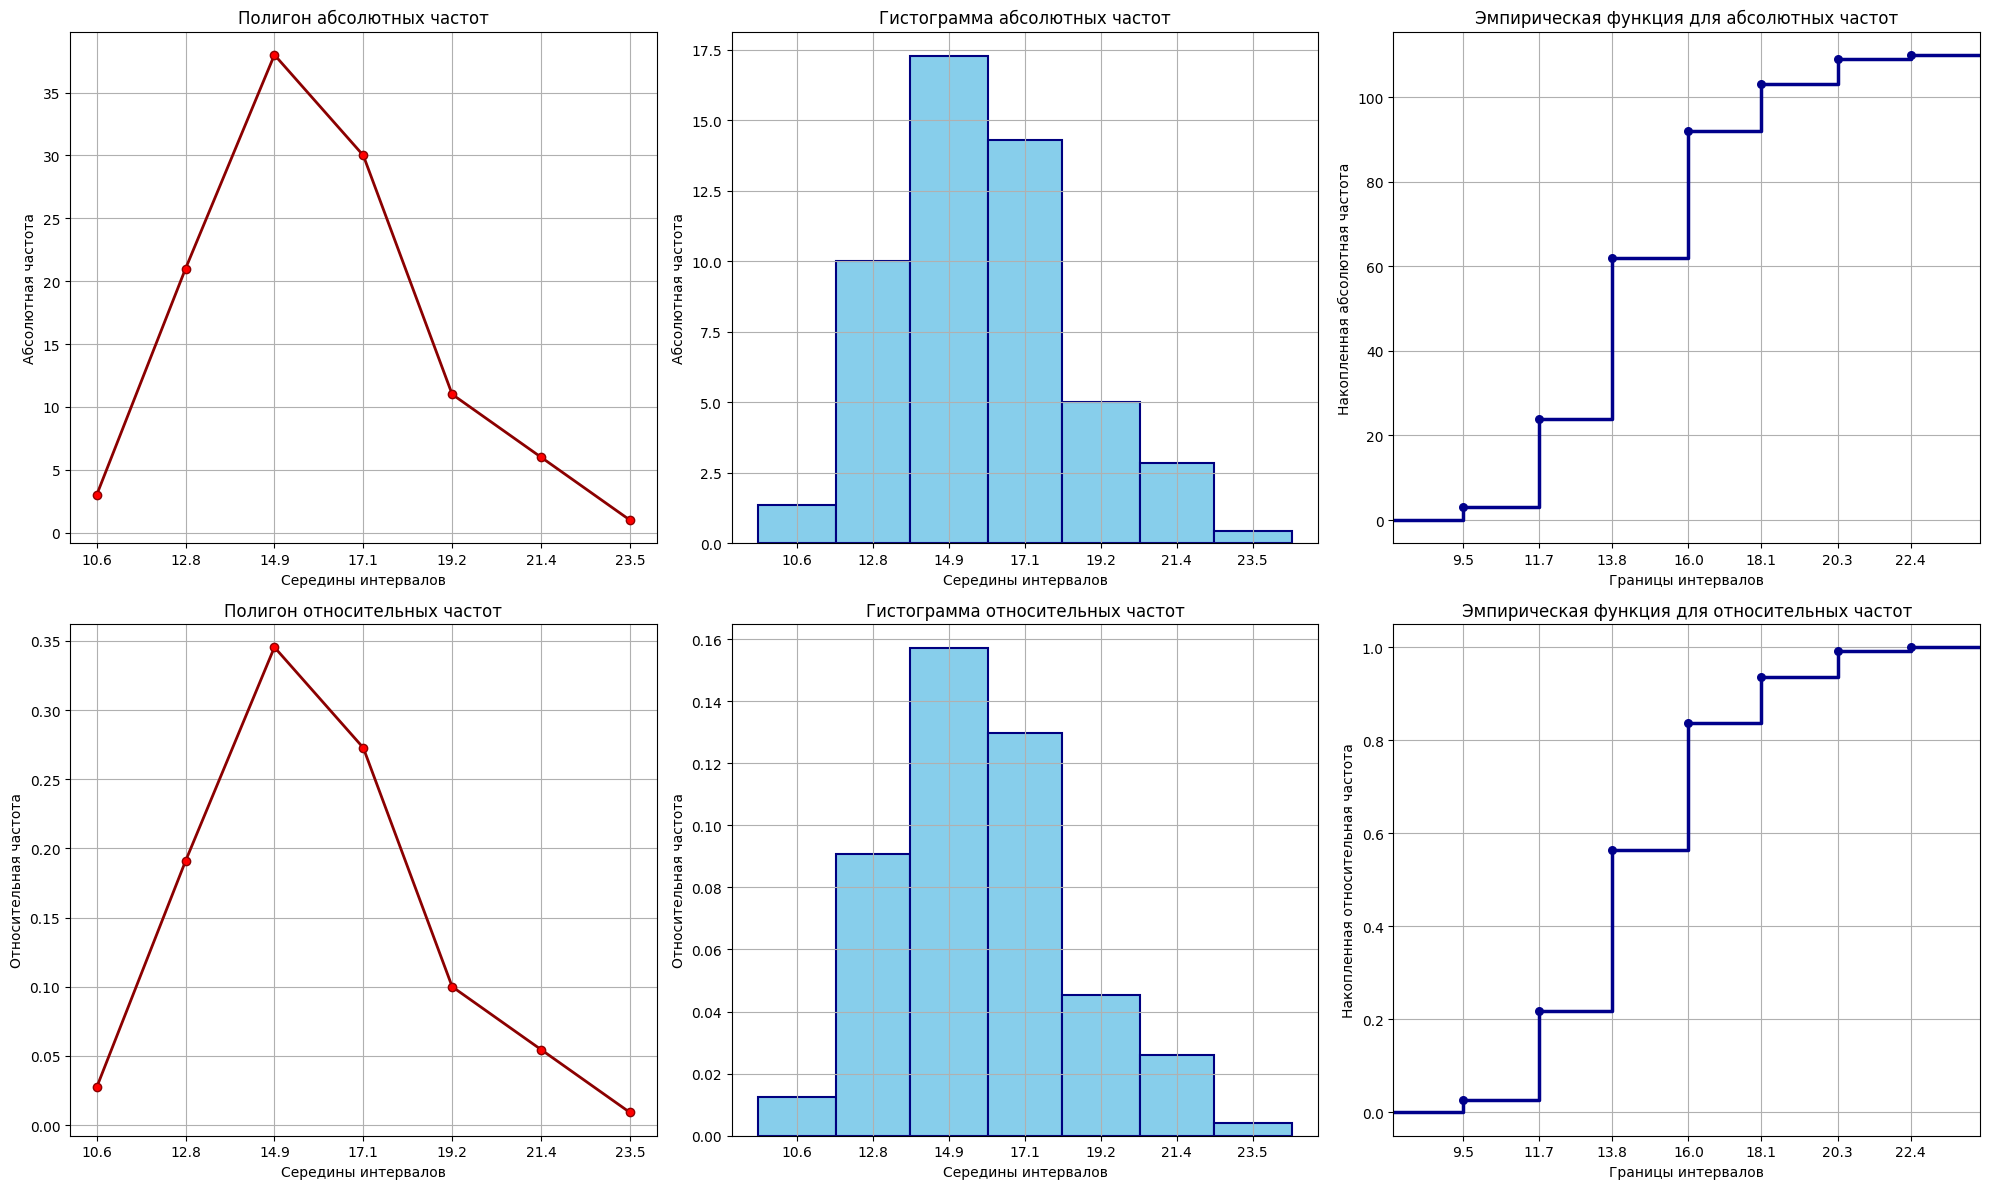

In [ ]:
# Извлечение второй выборки из файла
df_file = pd.read_csv("auto-mpg.txt", sep='\\s+', header=None, na_values='?')
sample_df = df_file.sample(n=110, random_state=24)
df = pd.DataFrame({'displacement': sample_df[0], 'acceleration': sample_df[5]}).reset_index(drop=True)
accel_data = df['acceleration']

# Построение и вывод интервального ряда
N = 110
k = int(1 + 3.31 * np.log10(N))
h = (max(accel_data) - min(accel_data)) / k

intervals = [round(min(accel_data) + i * h, 1) for i in range(k + 1)]
interval_data = []
for i in range(k):
    left, right = intervals[i], intervals[i + 1]
    interval_data.append([i + 1, left, right, []])

for val in accel_data:
    for i, left, right, vals in interval_data:
        if (i == k and left <= val <= right) or (i < k and left <= val < right):
            vals.append(val)
            break

print("-" * 77)
print("|  i  |     Интервал     |   ~x_i  |   m_i  |   ~m_i   | m_нак_i | ~m_нак_i |")
print("-" * 77)

abs_acc_m_i = 0
intervals_mid = []
frequencies_abs = []
accumulated_freq_abs = []
intervals_left = []
intervals_right = []

for i, left, right, vals in interval_data:
    abs_m_i = len(vals)
    abs_acc_m_i += abs_m_i
    rel_m_i = round(abs_m_i / N, 4)
    rel_acc_m_i = round(abs_acc_m_i / N, 4)
    mid = round((left + right) / 2, 2)

    intervals_mid.append(mid)
    frequencies_abs.append(abs_m_i)
    accumulated_freq_abs.append(abs_acc_m_i)
    intervals_left.append(left)
    intervals_right.append(right)

    if i == k:
        interval_str = f"[{left:.1f}, {right:.1f}]"
    else:
        interval_str = f"[{left:.1f}, {right:.1f})"

    print(f"| {i:2d}  |  {interval_str:14s}  |  {mid:5.2f}  |  {abs_m_i:3d}   |  {rel_m_i:.4f}  |  {abs_acc_m_i:4d}   |  {rel_acc_m_i:.4f}  |")

print("-" * 77)
print(f"|                Σ                 |  {abs_acc_m_i:4d}  |   {rel_acc_m_i:.2f}   |         -          |")
print("-" * 77)

# Подготовка данных для построения графиков
frequencies_rel = [freq / N for freq in frequencies_abs]
accumulated_freq_rel = [acc / N for acc in accumulated_freq_abs]
x_step = [0] + intervals
y_step_abs = [0] + accumulated_freq_abs + [1.0]
y_step_rel = [0] + accumulated_freq_rel + [1.0]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Полигон абсолютных частот
ax = axes[0, 0]
ax.plot(intervals_mid, frequencies_abs, 'o-', color='darkred', linewidth=2, markersize=6, markerfacecolor='red')
ax.set_xticks(intervals_mid)
ax.set_xticklabels([f'{x:.1f}' for x in intervals_mid])
ax.set_title('Полигон абсолютных частот')
ax.set_xlabel('Середины интервалов')
ax.set_ylabel('Абсолютная частота')
ax.grid()

# Гистограмма абсолютных частот
ax = axes[0, 1]
for i in range(k):
    left = intervals_left[i]
    right = intervals_right[i]
    width = right - left
    height = frequencies_abs[i] / width
    ax.bar(left, height, width, align='edge', color='skyblue', edgecolor='navy', linewidth=1.5)
ax.set_xticks(intervals_mid)
ax.set_xticklabels([f'{x:.1f}' for x in intervals_mid])
ax.set_title('Гистограмма абсолютных частот')
ax.set_xlabel('Середины интервалов')
ax.set_ylabel('Абсолютная частота')
ax.grid()

# Эмпирическая функция распределения для абсолютных частот
ax = axes[0, 2]
ax.step(x_step, y_step_abs, where='post', linewidth=2.5, color='darkblue')
ax.scatter(x_step[:-1], y_step_abs[:-1], color='darkblue', s=30, zorder=5)
ax.set_xticks(x_step)
ax.set_xticklabels([f'{x:.1f}' for x in x_step])
ax.set_title('Эмпирическая функция для абсолютных частот')
ax.set_ylabel('Накопленная абсолютная частота')
ax.set_xlabel('Границы интервалов')
ax.set_xlim(7.5, 24.4)
ax.grid()

# Полигон относительных частот
ax = axes[1, 0]
ax.plot(intervals_mid, frequencies_rel, 'o-', color='darkred', linewidth=2, markersize=6, markerfacecolor='red')
ax.set_xticks(intervals_mid)
ax.set_xticklabels([f'{x:.1f}' for x in intervals_mid])
ax.set_title('Полигон относительных частот')
ax.set_xlabel('Середины интервалов')
ax.set_ylabel('Относительная частота')
ax.grid()

# Гистограмма относительных частот
ax = axes[1, 1]
for i in range(k):
    left = intervals_left[i]
    right = intervals_right[i]
    width = right - left
    height = frequencies_rel[i] / width
    ax.bar(left, height, width, align='edge', color='skyblue', edgecolor='navy', linewidth=1.5)
ax.set_xticks(intervals_mid)
ax.set_xticklabels([f'{x:.1f}' for x in intervals_mid])
ax.set_title('Гистограмма относительных частот')
ax.set_xlabel('Середины интервалов')
ax.set_ylabel('Относительная частота')
ax.grid()

# Эмпирическая функция распределения для относительных частот
ax = axes[1, 2]
ax.step(x_step, y_step_rel, where='post', linewidth=2.5, color='darkblue')
ax.scatter(x_step[:-1], y_step_rel[:-1], color='darkblue', s=30, zorder=5)
ax.set_xticks(x_step)
ax.set_xticklabels([f'{x:.1f}' for x in x_step])
ax.set_title('Эмпирическая функция для относительных частот')
ax.set_ylabel('Накопленная относительная частота')
ax.set_xlabel('Границы интервалов')
ax.set_xlim(7.5, 24.4)
ax.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Интервальный ряд
df_int = pd.DataFrame({'i': range(1, k+1), 'left': intervals_left, 'right': intervals_right, 'x_i': intervals_mid, 'm_i': frequencies_abs})

# Выбор условного нуля C
modal_idx = df_int['m_i'].idxmax()
C = df_int.loc[modal_idx, 'x_i']
h = intervals_right[0] - intervals_left[0]

# Вычисление условных вариант u_i
df_int['u_i'] = ((df_int['x_i'] - C) / h).round().astype(int)
df_int['n_i*u_i'] = df_int['m_i'] * df_int['u_i']
df_int['n_i*u_i^2'] = df_int['m_i'] * (df_int['u_i'] ** 2)
df_int['n_i*u_i^3'] = df_int['m_i'] * (df_int['u_i'] ** 3)
df_int['n_i*u_i^4'] = df_int['m_i'] * (df_int['u_i'] ** 4)
df_int['n_i*(u_i+1)^4'] = df_int['m_i'] * ((df_int['u_i'] + 1) ** 4)

# Вычисление и запись итоговых сумм
sum_n = df_int['m_i'].sum()
sum_n_u = df_int['n_i*u_i'].sum()
sum_n_u2 = df_int['n_i*u_i^2'].sum()
sum_n_u3 = df_int['n_i*u_i^3'].sum()
sum_n_u4 = df_int['n_i*u_i^4'].sum()
sum_n_u_plus1_4 = df_int['n_i*(u_i+1)^4'].sum()

sums_row = pd.DataFrame([{
    'i': 'Σ',
    'x_i': '-',
    'm_i': sum_n,
    'u_i': '-',
    'n_i*u_i': sum_n_u,
    'n_i*u_i^2': sum_n_u2,
    'n_i*u_i^3': sum_n_u3,
    'n_i*u_i^4': sum_n_u4,
    'n_i*(u_i+1)^4': sum_n_u_plus1_4
}])

df_with_sums = pd.concat([df_int, sums_row], ignore_index=True)

# Вывод таблицы
display_cols = ['i', 'x_i', 'm_i', 'u_i', 'n_i*u_i', 'n_i*u_i^2', 'n_i*u_i^3', 'n_i*u_i^4', 'n_i*(u_i+1)^4']
print(tabulate(df_with_sums[display_cols].rename(columns={'m_i': 'n_i'}), headers='keys', tablefmt='grid', showindex=False))

# Контроль вычислений по формуле: Σn*(u+1)^4 = Σn*u^4 + 4Σn*u^3 + 6Σn*u^2 + 4Σn*u + N
control = sum_n + 4*sum_n_u + 6*sum_n_u2 + 4*sum_n_u3 + sum_n_u4
print(f"\nКонтроль вычислений: N + 4*Σnu + 6*Σnu² + 4*Σnu³ + Σnu⁴ = {sum_n} + 4*{sum_n_u} + 6*{sum_n_u2} + 4*{sum_n_u3} + {sum_n_u4} = {control}")
print(f"Сумма по столбцу n_i*(u_i+1)^4: {sum_n_u_plus1_4}\n")

# Вычисление условных эмпирических моментов M_k*
M1 = sum_n_u / N
M2 = sum_n_u2 / N
M3 = sum_n_u3 / N
M4 = sum_n_u4 / N

# Вычисление центральных эмпирических моментов m_k
m1_central = 0
m2_central = (M2 - M1**2) * (h**2)
m3_central = (M3 - 3 * M1 * M2 + 2 * (M1**3)) * (h**3)
m4_central = (M4 - 4 * M1 * M3 + 6 * (M1**2) * M2 - 3 * (M1**4)) * (h**4)

# Вычисление выборочных среднего, дисперсии, СКО и исправленных выборочной дисперсии и СКО
x_v = np.sum(df_int['x_i'] * df_int['m_i']) / N
D_v = np.sum(df_int['m_i'] * (df_int['x_i'] - x_v)**2) / N
sigma_v = np.sqrt(D_v)
s2 = (N / (N - 1)) * D_v
s = np.sqrt(s2)

# Вычисление коэффициентов асимметрии и эксцесса
As = m3_central / (s**3)
E = m4_central / (s**4) - 3

# Вычисление моды
x_low_modal = df_int.loc[modal_idx, 'left']
f_modal = df_int.loc[modal_idx, 'm_i'] / N
f_prev_modal = df_int.loc[modal_idx - 1, 'm_i'] / N if modal_idx > 0 else 0
f_next_modal = df_int.loc[modal_idx + 1, 'm_i'] / N if modal_idx < k - 1 else 0
Mo = x_low_modal + h * (f_modal - f_prev_modal) / ((f_modal - f_prev_modal) + (f_modal - f_next_modal))

# Вычисление медианы
median_idx = df_int[df_int['m_i'].cumsum() >= N / 2].index[0]
x_low_med = df_int.loc[median_idx, 'left']
f_med = df_int.loc[median_idx, 'm_i'] / N
acc_prev_med = df_int.loc[:median_idx-1, 'm_i'].sum() / N if median_idx > 0 else 0
Me = x_low_med + h * (0.5 - acc_prev_med) / f_med

# Вычисление коэффициента вариации
V = (sigma_v / x_v) * 100

# Вывод результатов
results = {
    'Параметр': [
        'Выборочное среднее (x_в)',
        'Выборочная дисперсия (D_в)',
        'Выборочное СКО (σ_в)',
        'Исправленная дисперсия (s²)',
        'Исправленное СКО (s)',
        'Коэф. асимметрии (As)',
        'Коэф. эксцесса (E)',
        'Мода (Mo)',
        'Медиана (Me)',
        'Коэф. вариации (V*)'
    ],
    'Значение': [
        round(x_v, 2),
        round(D_v, 2),
        round(sigma_v, 4),
        round(s2, 2),
        round(s, 4),
        round(As, 2),
        round(E, 2),
        round(Mo, 2),
        round(Me, 2),
        round(V, 2)
    ]
}

results_df = pd.DataFrame(results)
print(tabulate(results_df, headers='keys', tablefmt='grid', showindex=False))

+-----+-------+-------+-------+-----------+-------------+-------------+-------------+-----------------+
| i   | x_i   |   n_i | u_i   |   n_i*u_i |   n_i*u_i^2 |   n_i*u_i^3 |   n_i*u_i^4 |   n_i*(u_i+1)^4 |
+=====+=======+=======+=======+===========+=============+=============+=============+=================+
| 1   | 10.6  |     3 | -2    |        -6 |          12 |         -24 |          48 |               3 |
+-----+-------+-------+-------+-----------+-------------+-------------+-------------+-----------------+
| 2   | 12.75 |    21 | -1    |       -21 |          21 |         -21 |          21 |               0 |
+-----+-------+-------+-------+-----------+-------------+-------------+-------------+-----------------+
| 3   | 14.9  |    38 | 0     |         0 |           0 |           0 |           0 |              38 |
+-----+-------+-------+-------+-----------+-------------+-------------+-------------+-----------------+
| 4   | 17.05 |    30 | 1     |        30 |          30 |       

По интервальному ряду видно, что максимальная частота ($34,55%$) приходится на интервал $13,8 - 16,0$. Соседние интервалы также имеют высокие частоты, а крайние интервалы – низкую концентрацию значений. Следовательно, можно сделать вывод о том, что основная масса наблюдений сосредоточена в центре распределения с небольшим смещением к меньшим значениям.

Это подтверждается формой гистограммы и полигона частот: распределение одновершинное, максимум достигается при значении середины интервала $14,9$, после чего частоты постепенно убывают, особенно в правой части. Таким образом, распределение имеет слабую правостороннюю асимметрию.

Эмпирическая функция имеет наиболее заметные скачки на интервалах с наибольшими частотами ($11,7 - 16,0$), тогда как в правой части рост замедляется, что указывает на малое количество больших значений. Это также подтверждает наличие правосторонней асимметрии.

Различие между выборочной ($6.59$) и исправленной дисперсией ($6.65$) обусловлено делением на $N-1$, что позволяет устранить смещение оценки. Исправленное СКО также немного больше выборочного и лучше отражает разброс данных.

Коэффициенты асимметрии и эксцесса положителены и равны $0,5$ и $0,31$ соответственно, что указывает на слабую правостороннюю асимметрию и небольшую островершинность распределения. Еще это подтверждается соотношением между модой, медианой и выборочным средним: $M_o < M_e < \bar{x}$ ($15,3 < 15,59 < 15,82$).

Коэффициент вариации равен 16,23%, что говорит об умеренной вариации признака и однородности совокупности.


## Задание 2

In [ ]:
# Получение данных для двух признаков
X_data = df['displacement'].values
Y_data = df['acceleration'].values

N = 110

# Определение количества интервалов для каждого признака
k_X = int(1 + 3.31 * np.log10(N))
k_Y = int(1 + 3.31 * np.log10(N))

# Определение границ интервалов для X
X_min, X_max = min(X_data), max(X_data)
h_X = (X_max - X_min) / k_X
X_intervals = [round(X_min + i * h_X, 2) for i in range(k_X + 1)]

# Определение границ интервалов для Y
Y_min, Y_max = min(Y_data), max(Y_data)
h_Y = (Y_max - Y_min) / k_Y
Y_intervals = [round(Y_min + i * h_Y, 2) for i in range(k_Y + 1)]

# Создание двумерной таблицы частот
freq_matrix = np.zeros((k_Y, k_X), dtype=int)

for x_val, y_val in zip(X_data, Y_data):
    x_idx = k_X - 1
    for i in range(k_X):
        if i < k_X - 1:
            if X_intervals[i] <= x_val < X_intervals[i + 1]:
                x_idx = i
                break
        else:
            if X_intervals[i] <= x_val <= X_intervals[i + 1]:
                x_idx = i
                break

    y_idx = k_Y - 1
    for j in range(k_Y):
        if j < k_Y - 1:
            if Y_intervals[j] <= y_val < Y_intervals[j + 1]:
                y_idx = j
                break
        else:
            if Y_intervals[j] <= y_val <= Y_intervals[j + 1]:
                y_idx = j
                break

    freq_matrix[y_idx, x_idx] += 1

x_headers = []
for i in range(k_X):
    if i < k_X - 1:
        x_headers.append(f"[{X_intervals[i]:.1f}, {X_intervals[i+1]:.1f})")
    else:
        x_headers.append(f"[{X_intervals[i]:.1f}, {X_intervals[i+1]:.1f}]")

y_headers = []
for j in range(k_Y):
    if j < k_Y - 1:
        y_headers.append(f"[{Y_intervals[j]:.1f}, {Y_intervals[j+1]:.1f})")
    else:
        y_headers.append(f"[{Y_intervals[j]:.1f}, {Y_intervals[j+1]:.1f}]")

# Вычисление сумм частот по строкам и столбцам
row_sums = np.sum(freq_matrix, axis=1)
col_sums = np.sum(freq_matrix, axis=0)
total_sum = np.sum(freq_matrix)

# Вывод и создание таблицы
df_2d = pd.DataFrame(freq_matrix, index=[f"{y_headers[j]}" for j in range(k_Y)], columns=[f"{x_headers[i]}" for i in range(k_X)])

table_data = []
header_row = ['Y \\ X'] + [f"{x_headers[i]}" for i in range(k_X)]
table_data.append(header_row)

for j in range(k_Y):
    row = [f"{y_headers[j]}"] + list(freq_matrix[j, :])
    table_data.append(row)

print(tabulate(table_data, tablefmt='grid', stralign='center', numalign='center'))

+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+
|    Y \ X     | [10.0, 15.2) | [15.2, 20.5) | [20.5, 25.7) | [25.7, 30.9) | [30.9, 36.1) | [36.1, 41.4) | [41.4, 46.6] |
+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+
| [9.5, 11.7)  |      1       |      1       |      0       |      0       |      1       |      0       |      0       |
+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+
| [11.7, 13.8) |      10      |      9       |      0       |      2       |      0       |      0       |      0       |
+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+
| [13.8, 16.0) |      3       |      6       |      13      |      8       |      7       |      1       |      0       |
+--------------+--------

## Задание 3

In [ ]:
# Вычисление середин интервалов
x_mid = [(X_intervals[i] + X_intervals[i+1]) / 2 for i in range(k_X)]
y_mid = [(Y_intervals[i] + Y_intervals[i+1]) / 2 for i in range(k_Y)]

# Формирование корреляционной таблицы
table_data = []
header_row = ['Y \\ X'] + [f"{x_mid[i]:.1f}" for i in range(k_X)] + ['Σ_y']
table_data.append(header_row)

for j in range(k_Y):
    row = [f"{y_mid[j]:.1f}"]
    for i in range(k_X):
        if freq_matrix[j, i] > 0:
            row.append(str(freq_matrix[j, i]))
        else:
            row.append('-')
    row.append(str(row_sums[j]))
    table_data.append(row)

footer_row = ['Σ_x'] + [str(col_sums[i]) for i in range(k_X)] + [str(total_sum)]
table_data.append(footer_row)

print(tabulate(table_data, tablefmt='grid', stralign='center', numalign='center'))

+-------+------+------+------+------+------+------+------+-----+
| Y \ X | 12.6 | 17.8 | 23.1 | 28.3 | 33.5 | 38.8 | 44.0 | Σ_y |
+-------+------+------+------+------+------+------+------+-----+
| 10.6  |  1   |  1   |  -   |  -   |  1   |  -   |  -   |  3  |
+-------+------+------+------+------+------+------+------+-----+
| 12.7  |  10  |  9   |  -   |  2   |  -   |  -   |  -   | 21  |
+-------+------+------+------+------+------+------+------+-----+
| 14.9  |  3   |  6   |  13  |  8   |  7   |  1   |  -   | 38  |
+-------+------+------+------+------+------+------+------+-----+
| 17.1  |  -   |  5   |  10  |  8   |  5   |  1   |  1   | 30  |
+-------+------+------+------+------+------+------+------+-----+
| 19.2  |  1   |  1   |  2   |  2   |  3   |  2   |  -   | 11  |
+-------+------+------+------+------+------+------+------+-----+
| 21.4  |  1   |  -   |  -   |  3   |  1   |  -   |  1   |  6  |
+-------+------+------+------+------+------+------+------+-----+
| 23.5  |  -   |  -   |  

По корреляционной таблице видно, что основная масса наблюдений сосредоточена в центральных значениях признаков: $X = 17,8 - 28,3$ и $Y = 14,9 - 17,1$. Крайние значения встречаются редко, что указывает на концентрацию данных вокруг средних значений признаков.

Частоты распределены с диагональной направленностью: при увеличении $X$ увеличиваются и значения $Y$, что говорит о наличии положительной корреляционной зависимости между признаками, однако эта связь не является строгой – наблюдается разброс частот относительно главной диагонали.


## Задание 4

In [ ]:
# Вычисление коэффициента корреляции по стандартной формуле
x_v = np.sum(x_mid * col_sums) / N
y_v = np.sum(y_mid * row_sums) / N

Sx = np.sqrt(np.sum(col_sums * (x_mid - x_v)**2) / N)
Sy = np.sqrt(np.sum(row_sums * (y_mid - y_v)**2) / N)

sum_nxy = 0
for i in range(k_X):
    for j in range(k_Y):
        sum_nxy += freq_matrix[j, i] * x_mid[i] * y_mid[j]

r_xy_standard = round((sum_nxy - N * x_v * y_v) / (N * Sx * Sy), 4)

print(f"Коэффициент корреляции, вычисленный по стандартной формуле: r_xy = {r_xy_standard}")

Коэффициент корреляции, вычисленный по стандартной формуле: r_xy = 0.4828


In [ ]:
# Вычисление коэффициента корреляции с помощью условных вариант
Cx = x_mid[np.argmax(col_sums)]
Cy = y_mid[np.argmax(row_sums)]

u = (np.array(x_mid) - Cx) / h_X
v = (np.array(y_mid) - Cy) / h_Y

sum_nu = np.sum(col_sums * u)
sum_nv = np.sum(row_sums * v)

sum_nu2 = np.sum(col_sums * u**2)
sum_nv2 = np.sum(row_sums * v**2)

sum_nuv = 0
for i in range(k_X):
    for j in range(k_Y):
        sum_nuv += freq_matrix[j,i] * u[i] * v[j]

u_mean = sum_nu / N
v_mean = sum_nv / N

sigma_u = np.sqrt(sum_nu2 / N - u_mean**2)
sigma_v = np.sqrt(sum_nv2 / N - v_mean**2)

r_xy_uv = round((sum_nuv - N * u_mean * v_mean) / (N * sigma_u * sigma_v), 4)

print(f"Коэффициент корреляции, вычисленный с помощью условных вариант: r_xy = {r_xy_uv}")

Коэффициент корреляции, вычисленный с помощью условных вариант: r_xy = 0.4828


Оба способа вычисления дали одинаковый результат: $r_{xy} = 0,4828$, что подтверждает правильность проведенных расчетов. Значение коэффициента корреляции указывает на умеренную положительную зависимость между признаками: при увеличении $X$ наблюдается склонность к увеличению $Y$, однако зависимость не является сильной и сопровождается разбросом значений. Следовательно, результаты согласуются с анализом корреляционной таблицы.

## Задание 5

In [ ]:
# Преобразование Фишера
z = 0.5 * np.log((1 + r_xy_standard) / (1 - r_xy_standard))

# Вычисление СКО величины z
sigma_z = 1 / np.sqrt(N - 3)

# Уровни доверия
gamma_values = [0.95, 0.99]

# Вычисление доверительного интервала
for gamma in gamma_values:
    lambda_val = stats.norm.ppf((1 + gamma) / 2)

    z_lower = z - lambda_val * sigma_z
    z_upper = z + lambda_val * sigma_z

    r_lower = round(np.tanh(z_lower), 4)
    r_upper = round(np.tanh(z_upper), 4)

    print(f"γ = {gamma}")
    print(f"Доверительный интервал для r_xy: ({r_lower}, {r_upper})\n")

γ = 0.95
Доверительный интервал для r_xy: (0.3249, 0.6145)

γ = 0.99
Доверительный интервал для r_xy: (0.2707, 0.6502)



Оба построенных интервала с заданной надежностью покрывают значение коэффициента корреляции. При увеличении уровня надежности с 0,95 до 0,99 границы интервала расширяются, поскольку для более надежной оценки необходимо учитывать более широкий диапазон возможных значений. Доверительные интервалы лежат в положительной области, следовательно, можно сказать, что корреляционная связь между признаками является положительной.


## Задание 6

In [ ]:
# Уровень значимости
alpha = 0.05

# Вычисление наблюдаемого значения
T_obs = round(r_xy_standard * np.sqrt(N - 2) / np.sqrt(1 - r_xy_standard**2), 4)
print(f"T_набл = {T_obs}")

# Вычисление критического значения
t_crit = round(stats.t.ppf(1 - alpha / 2, df=N - 2), 4)
print(f"t_крит = {t_crit}\n")

# Проверка гипотезы
if abs(T_obs) <= t_crit:
    print("Нет оснований отвергать гипотезу H0.")
    print("Выборочный коэффициент корреляции незначим.")
else:
    print("Гипотеза H0 отвергается.")
    print("Выборочный коэффициент корреляции значим.")

T_набл = 5.7294
t_крит = 1.9822

Гипотеза H0 отвергается.
Выборочный коэффициент корреляции значим.


Так как наблюдаемое значение $T_{набл}$ оказалось больше критического, нулевая гипотеза отвергается на уровне значимости $\alpha = 0,05$. Это говорит о статистической значимости выборочного коэффициента корреляции и наличии между признаками умеренной линейной корреляционной связи.

## Выводы

В ходе выполнения практической работы была проведена статистическая обработка второй выборки, включающая построение интервального вариационного ряда и вычисление точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, СКО, асимметрии, эксцесса и коэффициента вариации). Полученные результаты показали, что распределение близко к нормальному, имеет выраженный центр и умеренную правостороннюю асимметрию, при этом значения признака в основном сосредоточены в центральных интервалах. На основе интервального ряда были построены полигоны, гистограммы  и эмпирические функции распределения для абсолютных и относительных частот, которые подтвердили выводы о форме распределения и концентрации наблюдений.

Были построены двумерный интервальный вариационный ряд и корреляционная таблица, анализ которых показал, что основная масса наблюдений сосредоточена в области центральных значений обоих признаков, тогда как крайние значения встречаются редко. На основе этого был сделан вывод о наличии умеренной положительной зависимости между исследуемыми признаками.

Также был вычислен выборочный коэффициент корреляции по стандартной формуле и методом условных вариант. Для него был построен доверительный интервал при уровнях надежности $\gamma = 0,95$ и $\gamma = 0,99$, при этом увеличение уровня доверия привело к расширению интервала оценок.

Была проверена гипотеза о равенстве коэффициента корреляции нулю при $\alpha = 0,05$. В результате сравнения наблюдаемого и критического значений нулевая гипотеза была отвергнута, что говорит о статистической значимости выявленной корреляционной зависимости между признаками.